<a href="https://colab.research.google.com/github/sejalpandey30/LivenessDetection/blob/main/NHAI_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset setup as the exectution will be for the yolo model based**

In [ ]:
!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("atulanandjha/lfwpeople")
print(path)

Using Colab cache for faster access to the 'lfwpeople' dataset.
/kaggle/input/lfwpeople


In [ ]:
import os
for file in os.listdir(path):
   print(file)

pairsDevTrain.txt
lfw-funneled.tgz
pairsDevTest.txt
pairs.txt


In [ ]:
import tarfile
import os

tgz_path = os.path.join(path,"lfw-funneled.tgz")
extract_path = "/content/lfw"
with tarfile.open(tgz_path) as tar:
    tar.extractall(extract_path)
print("extracted")

/tmp/ipykernel_6175/1780434490.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


extracted


In [ ]:
dataset_path = "/content/lfw/lfw_funneled"
print(os.listdir(dataset_path))

['Nathalie_Dechy', 'Kaio_Almeida', 'John_Lennon', 'Yogi_Berra', 'Mikhail_Khodorkovsky', 'Pedro_Martinez', 'Darrell_Dickey', 'Masaru_Hayami', 'Jaromir_Jagr', 'John_Cusack', 'Denise_van_Outen', 'Akiko_Morigami', 'Miguel_Estrada', 'Cameron_Diaz', 'Ahmet_Demir', 'Asmaa_Assad', 'Robert_Lee_Yates_Jr', 'Nathalie_Gagnon', 'Sun_Myung_Moon', 'David_Scott_Morris', 'Stuart_Knoll', 'Alexis_Dennisoff', 'Eddie_Compass', 'Bernice_Wong', 'Melina_Kanakaredes', 'Al_Pacino', 'Martin_Gecht', 'Charles_Moose', 'Marsah_Ambrosius', 'Bonnie_Hunt', 'Caroline_Kennedy', 'Steve_Nesbitt', 'Pete_Carroll', 'Eric_Christian_Olsen', 'Gabi_Zimmer', 'Marisol_Breton', 'Lynn_Abraham', 'Ernest_Hollings', 'Mary_Landrieu', 'Dora_Bakoyianni', 'Joseph_Ganim', 'Alfredo_Pena', 'Martha_Bowen', 'Karen_Pereiras', 'Colleen_Ryan', 'Elvis_Stojko', 'Claudia_Schiffer', 'Igor_Ivanov', 'Rob_Morrow', 'Rudolph_Holton', 'Jonathan_Mostow', 'Uma_Thurman', 'Jane_Russell', 'Jerry_Angelo', 'Helio_Castroneves', 'Bertie_Ahern', 'Saddam_Hussein', 'Ring

# **Downloading the required packages as per the requirment**

In [ ]:
!pip install insightface
!pip install onnxruntime
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 75.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.0 MB/s eta 0:00:00


In [ ]:
from insightface.app import FaceAnalysis
app = FaceAnalysis(name = 'buffalo_l')
app.prepare(ctx_id = -1)

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:14<00:00, 19479.37KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: [(128, 128), (640, 640)

In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


appending the name of people in the dataset, here we are categorizing the number of folders availble in the dataset for the segreggation of the data only when there are duplicate images available for that particular person, to ensure we have datafor training and testing

In [ ]:
people = []
for person in os.listdir(dataset_path):
  person_path = os.path.join(dataset_path,person)
  if os.path.isdir(person_path):
      if(len(os.listdir(person_path))>=2):
         people.append(person)
people = people[:20]
print(people)

['John_Cusack', 'Miguel_Estrada', 'Cameron_Diaz', 'Al_Pacino', 'Charles_Moose', 'Caroline_Kennedy', 'Pete_Carroll', 'Lynn_Abraham', 'Mary_Landrieu', 'Martha_Bowen', 'Claudia_Schiffer', 'Igor_Ivanov', 'Jonathan_Mostow', 'Uma_Thurman', 'Bertie_Ahern', 'Saddam_Hussein', 'Vicente_Fernandez', 'Hamzah_Haz', 'James_Wolfensohn', 'Vaclav_Klaus']


here the given code is create embedding using the cv2 library

In [ ]:
import cv2
face_db ={}
for person in people:
  person_path = os.path.join(dataset_path,person)
  images = sorted(os.listdir(person_path))
  embeddings = []
  for img_name in images[:3]:
    img_path = os.path.join(person_path, img_name)
    img = cv2.imread(img_path)
    faces = app.get(img)
    if len(faces)>0:
      embeddings.append(faces[0].embedding)
if len(embeddings)>0:
  face_db[person] = embeddings
#print(face_db)

In [ ]:
import numpy as np
THRESHOLD = 0.55
def cosine_similarity(a,b):
  return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))

def identify_person(query_embedding):
  best_person ="Unknown"
  best_score = -1
  for person, embeddings in face_db.items():
    for emb in embeddings:
      score = cosine_similarity(query_embedding,emb)
      if score>best_score:
        best_score = score
        best_person = person
    if best_score <THRESHOLD:
      return "Unknown",best_score
  return best_person,best_score

In [ ]:
test_person = list(face_db.keys())[0]
print(test_person)

Vaclav_Klaus


In [ ]:
person_path = os.path.join(dataset_path,test_person)
images = sorted([img for img in os.listdir(person_path)
    if img.lower().endswith((".jpg", ".jpeg", ".png"))
])

test_path = os.path.join(person_path,images[-1])

print(test_path)

/content/lfw/lfw_funneled/Vaclav_Klaus/Vaclav_Klaus_0002.jpg


In [ ]:
test_img = cv2.imread(test_path)

faces = app.get(test_img)

if len(faces) > 0:

    test_emb = faces[0].embedding

    predicted_person, score = identify_person(test_emb)

    print("Actual:", test_person)
    print("Predicted:", predicted_person)
    print("Score:", score)

else:

    print("No face detected")

Actual: Vaclav_Klaus
Predicted: Vaclav_Klaus
Score: 1.0


In [ ]:
import pickle

with open(
    "face_db_small.pkl",
    "wb"
) as f:

    pickle.dump(face_db, f)

print("Database saved")

Database saved


In [ ]:
import pickle

with open(
    "face_db_small.pkl",
    "rb"
) as f:

    face_db = pickle.load(f)

print("Database loaded")
print(len(face_db))

Database loaded
20


In [ ]:
print("Database size:", len(face_db))

for i, (person, embeddings) in enumerate(face_db.items()):
    print(person, len(embeddings))

    if i >= 10:
        break

Database size: 20
John_Cusack 2
Miguel_Estrada 2
Cameron_Diaz 3
Al_Pacino 3
Charles_Moose 3
Caroline_Kennedy 3
Pete_Carroll 3
Lynn_Abraham 2
Mary_Landrieu 3
Martha_Bowen 2
Claudia_Schiffer 3


In [ ]:
import os
import cv2

face_db = {}

for person in people:

    person_path = os.path.join(dataset_path,person)

    images = sorted([
        img for img in os.listdir(person_path)
        if img.lower().endswith(
            (".jpg",".jpeg",".png")
        )
    ])

    embeddings = []

    for img_name in images[:3]:

        img_path = os.path.join(
            person_path,
            img_name
        )

        img = cv2.imread(img_path)

        if img is None:
            continue

        faces = app.get(img)

        if len(faces) == 0:
            continue

        embeddings.append(
            faces[0].embedding
        )

    if len(embeddings) > 0:

        # IMPORTANT
        face_db[person] = embeddings

print("Database size:", len(face_db))

Database size: 20


In [ ]:
print(len(face_db))

for person in list(face_db.keys())[:10]:
    print(
        person,
        len(face_db[person])
    )

20
John_Cusack 2
Miguel_Estrada 2
Cameron_Diaz 3
Al_Pacino 3
Charles_Moose 3
Caroline_Kennedy 3
Pete_Carroll 3
Lynn_Abraham 2
Mary_Landrieu 3
Martha_Bowen 2


In [ ]:
import pickle

with open(
    "face_db_small.pkl",
    "wb"
) as f:

    pickle.dump(
        face_db,
        f
    )

print("Saved")

Saved


image testing

In [ ]:
import os

test_person = "Lynn_Abraham"

person_path = os.path.join(
    dataset_path,
    test_person
)

images = sorted(os.listdir(person_path))

test_path = os.path.join(
    person_path,
    images[-1]
)

print(test_path)

/content/lfw/lfw_funneled/Lynn_Abraham/Lynn_Abraham_0002.jpg


In [ ]:
import cv2

test_img = cv2.imread(test_path)

faces = app.get(test_img)

if len(faces) > 0:

    test_emb = faces[0].embedding

    predicted_person, score = identify_person(test_emb)

    print("Actual:", test_person)
    print("Predicted:", predicted_person)
    print("Score:", score)

else:
    print("No face detected")

Actual: Lynn_Abraham
Predicted: Unknown
Score: -0.016697258


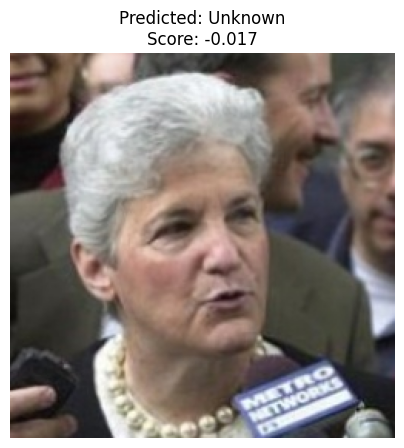

In [ ]:
from matplotlib import pyplot as plt
import cv2

img_rgb = cv2.cvtColor(
    test_img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.title(
    f"Predicted: {predicted_person}\nScore: {score:.3f}"
)
plt.axis("off")
plt.show()

plotting

In [ ]:
def top_matches(query_embedding):

    results = []

    for person, embeddings in face_db.items():

        best_score = max(
            cosine_similarity(query_embedding, emb)
            for emb in embeddings
        )

        results.append((person, best_score))

    results.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return results[:20]

In [ ]:
import cv2

test_img = cv2.imread(test_path)

faces = app.get(test_img)

test_emb = faces[0].embedding

matches = top_matches(test_emb)

print(matches)

[('Lynn_Abraham', np.float32(1.0000001)), ('James_Wolfensohn', np.float32(0.13350117)), ('Al_Pacino', np.float32(0.11446672)), ('Caroline_Kennedy', np.float32(0.0942238)), ('Igor_Ivanov', np.float32(0.09312428)), ('Pete_Carroll', np.float32(0.090999715)), ('Cameron_Diaz', np.float32(0.07059768)), ('Jonathan_Mostow', np.float32(0.05153963)), ('Vaclav_Klaus', np.float32(0.04768101)), ('Bertie_Ahern', np.float32(0.04426796)), ('Saddam_Hussein', np.float32(0.034566693)), ('Mary_Landrieu', np.float32(0.030932145)), ('Charles_Moose', np.float32(0.027882649)), ('Martha_Bowen', np.float32(0.012771005)), ('Hamzah_Haz', np.float32(0.0010786159)), ('Claudia_Schiffer', np.float32(-0.0006377389)), ('Vicente_Fernandez', np.float32(-0.0013295326)), ('Miguel_Estrada', np.float32(-0.0040568416)), ('John_Cusack', np.float32(-0.016697258)), ('Uma_Thurman', np.float32(-0.06337854))]


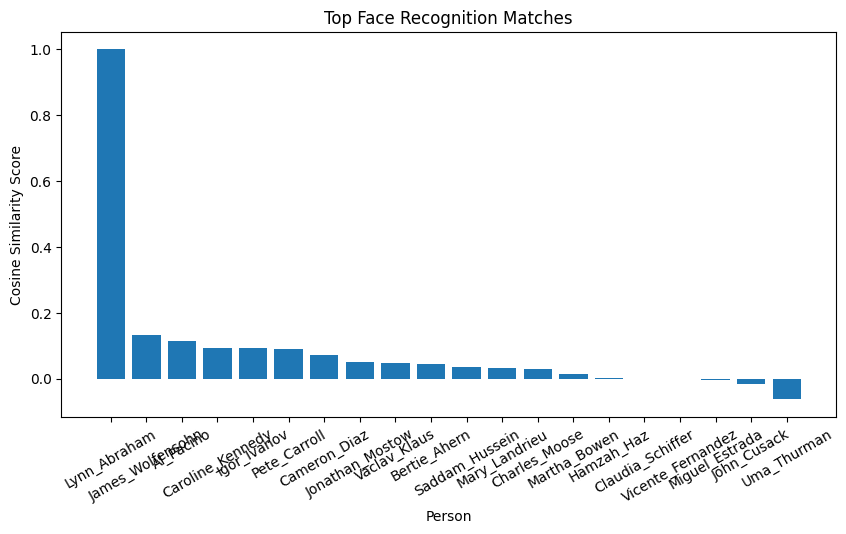

In [ ]:
import matplotlib.pyplot as plt

names = [x[0] for x in matches]
scores = [x[1] for x in matches]

plt.figure(figsize=(10,5))

plt.bar(names, scores)

plt.title("Top Face Recognition Matches")
plt.ylabel("Cosine Similarity Score")
plt.xlabel("Person")

plt.xticks(rotation=30)

plt.show()

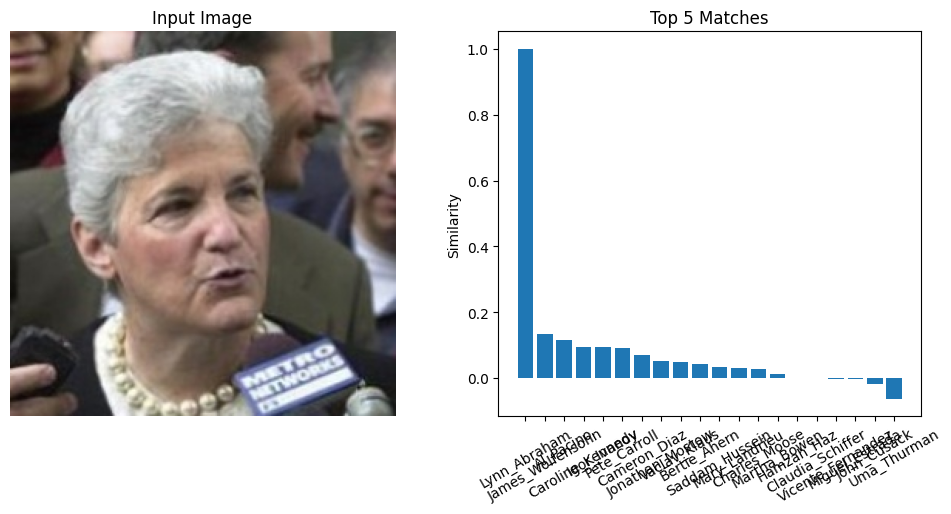

In [ ]:
import matplotlib.pyplot as plt
import cv2

img_rgb = cv2.cvtColor(
    test_img,
    cv2.COLOR_BGR2RGB
)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Image
ax[0].imshow(img_rgb)
ax[0].set_title("Input Image")
ax[0].axis("off")

# Similarity Graph
ax[1].bar(names, scores)
ax[1].set_title("Top 5 Matches")
ax[1].set_ylabel("Similarity")

plt.xticks(rotation=30)

plt.show()

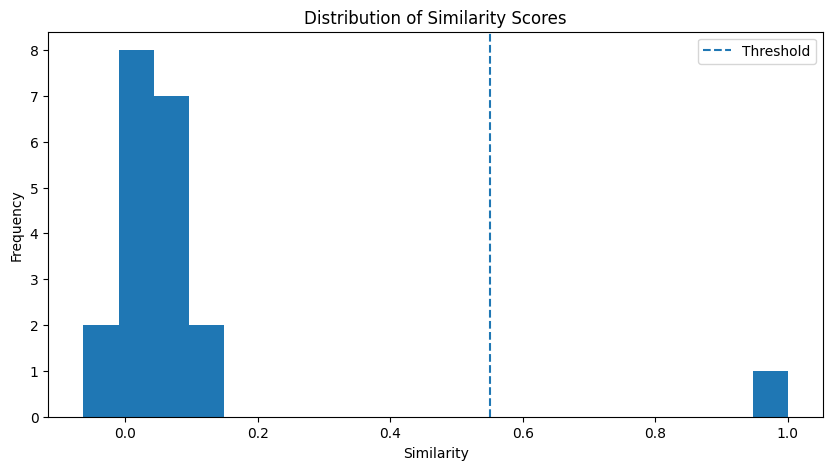

In [ ]:
all_scores = []

for person, embeddings in face_db.items():

    best = max(
        cosine_similarity(test_emb, emb)
        for emb in embeddings
    )

    all_scores.append(best)

plt.figure(figsize=(10,5))

plt.hist(all_scores, bins=20)

plt.axvline(
    THRESHOLD,
    linestyle="--",
    label="Threshold"
)

plt.title("Distribution of Similarity Scores")
plt.xlabel("Similarity")
plt.ylabel("Frequency")
plt.legend()

plt.show()

video test for identification

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.mp4 to test.mp4


In [ ]:
video_path = list(uploaded.keys())[0]
print(video_path)

test.mp4


In [ ]:
import cv2
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(fps,width,height,frames)

30 720 1280 348


In [ ]:
import cv2
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)



In [ ]:
import cv2

cap = cv2.VideoCapture(video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width,height)
)

frame_count = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    faces = app.get(frame)

    for face in faces:

        emb = face.embedding

        person, score = identify_person(
            emb
        )

        bbox = face.bbox.astype(int)

        x1,y1,x2,y2 = bbox

        cv2.rectangle(
            frame,
            (x1,y1),
            (x2,y2),
            (0,255,0),
            2
        )

        cv2.putText(
            frame,
            f"{person} {score:.2f}",
            (x1,y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0,255,0),
            2
        )

    out.write(frame)

print("Frames processed:", frame_count)

cap.release()
out.release()

print("Done")

Frames processed: 348
Done


In [ ]:
from google.colab import files
files.download("output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

video test evaluation done
- result found out that the video has stable is better in recognizing unknown face and giving a good accuracy as per expectation
- till this point we have correctly trained the model for face detection and have generated one sample output for reference.


**we have to move towards the liveness of the model by adding blink detection**

facial coordinates using insight library in yolo model

In [ ]:
from insightface.app import FaceAnalysis
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=-1)

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: [(128, 128), (640, 640)

In [ ]:
img = cv2.imread(test_path)
faces = app.get(img)
face = faces[0]
print(face)

{'bbox': array([     76.778,      60.362,      176.48,      197.94], dtype=float32), 'kps': array([[     96.279,      115.81],
       [     141.01,      113.86],
       [     115.67,      146.69],
       [     101.79,      163.16],
       [     144.47,      161.36]], dtype=float32), 'det_score': np.float32(0.9040352), 'landmark_3d_68': array([[     77.985,      110.96,      83.176],
       [     80.323,      125.82,      82.322],
       [     82.204,      141.14,      80.252],
       [     84.472,      155.61,      75.223],
       [     87.604,      168.79,      63.412],
       [     93.363,      178.61,      52.561],
       [     99.639,      186.29,      42.655],
       [     107.06,      192.65,       30.18],
       [     121.59,      196.36,      22.563],
       [     137.82,      192.05,      25.351],
       [     150.48,      183.82,      35.048],
       [     161.11,      174.09,      43.856],
       [     168.49,       164.7,      53.585],
       [     172.83,      154.34,     

In [ ]:
print(dir(face))

['__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__ior__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__or__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__ror__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'age', 'bbox', 'clear', 'copy', 'det_score', 'embedding', 'embedding_norm', 'fromkeys', 'gender', 'get', 'items', 'keys', 'kps', 'landmark_2d_106', 'landmark_3d_68', 'normed_embedding', 'pop', 'popitem', 'pose', 'setdefault', 'sex', 'update', 'values']


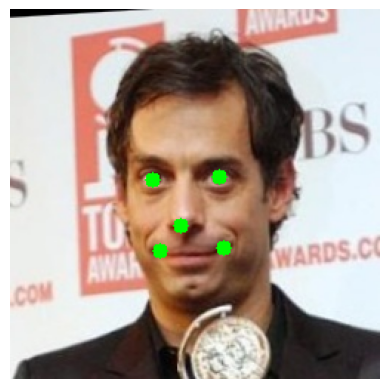

In [ ]:
import matplotlib.pyplot as plt

img = cv2.imread(test_path)

faces = app.get(img)

face = faces[0]

kps = face.kps

for point in kps:

    x,y = point.astype(int)

    cv2.circle(
        img,
        (x,y),
        5,
        (0,255,0),
        -1
    )

plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
import cv2
import numpy as np

cap = cv2.VideoCapture(video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "head_movement_output.mp4",
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

nose_positions = []

frame_count = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    faces = app.get(frame)

    for face in faces:

        # Bounding Box
        bbox = face.bbox.astype(int)

        x1, y1, x2, y2 = bbox

        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Keypoints
        kps = face.kps

        for point in kps:

            x, y = point.astype(int)

            cv2.circle(
                frame,
                (x, y),
                5,
                (0, 0, 255),
                -1
            )

        # Nose Point
        nose_x = kps[2][0]

        nose_positions.append(nose_x)

        cv2.putText(
            frame,
            "Tracking Head",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

    out.write(frame)

    if frame_count % 50 == 0:
        print("Processed:", frame_count)

cap.release()
out.release()

print("Video Processing Complete")

NameError: name 'video_path' is not defined

In [ ]:
if len(nose_positions) > 0:

    movement = max(nose_positions) - min(nose_positions)

    print("Nose Movement:", movement)

else:

    movement = 0

    print("No face detected")

NameError: name 'nose_positions' is not defined

In [ ]:
THRESHOLD = 20

if movement > THRESHOLD:

    print("LIVE PERSON")

else:

    print("NOT LIVE")

LIVE PERSON


In [ ]:
from google.colab import files

files.download("head_movement_output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
face = faces[0]
print(dir(face))

['__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__ior__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__or__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__ror__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'age', 'bbox', 'clear', 'copy', 'det_score', 'embedding', 'embedding_norm', 'fromkeys', 'gender', 'get', 'items', 'keys', 'kps', 'landmark_2d_106', 'landmark_3d_68', 'normed_embedding', 'pop', 'popitem', 'pose', 'setdefault', 'sex', 'update', 'values']


In [ ]:
if score >0.6 and movement >20:
  print("AUTHENTICATED")
else:
  print("UNAUTHENTICATED")


UNAUTHENTICATED


In [ ]:
print(dir(face))

['__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__ior__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__or__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__ror__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'age', 'bbox', 'clear', 'copy', 'det_score', 'embedding', 'embedding_norm', 'fromkeys', 'gender', 'get', 'items', 'keys', 'kps', 'landmark_2d_106', 'landmark_3d_68', 'normed_embedding', 'pop', 'popitem', 'pose', 'setdefault', 'sex', 'update', 'values']


In [ ]:
img = cv2.imread(test_path)

faces = app.get(img)

face = faces[0]

print(face.landmark_2d_106.shape)

(106, 2)


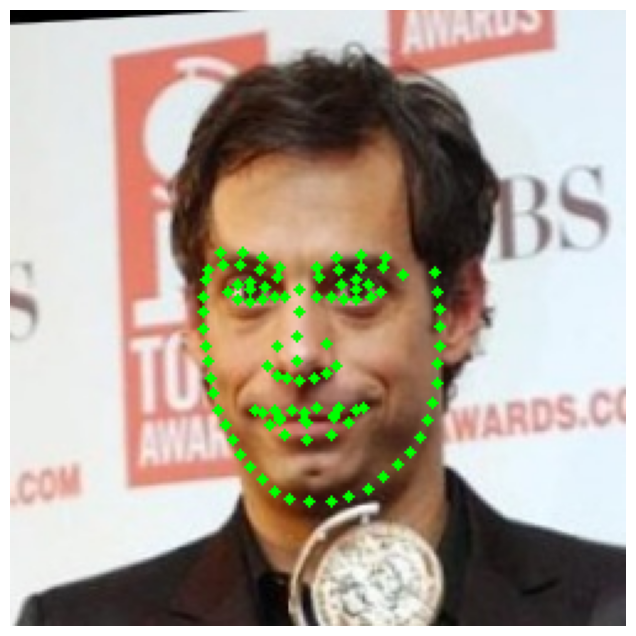

In [ ]:
img = cv2.imread(test_path)

faces = app.get(img)

face = faces[0]

landmarks = face.landmark_2d_106

for point in landmarks:

    x, y = point.astype(int)

    cv2.circle(
        img,
        (x,y),
        2,
        (0,255,0),
        -1
    )

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
print(face.pose)

[     -9.178     -9.1294    -0.10213]


here one more thing can be done in addition to the nose movement, we have considered the yaw angle , here instead of taking in account the nose movement value
- we are using the yaw angle inside the video can be taken(rn it is not done)
- the value can be caluculated by taking the max(yaw_value)- min(yaw_value)
and here if the movemnent is more than 15 degree we get that the person is live person
- much more relaiable method than rather using raw pixel movement
- so here with this we have completed the eye, mouth and nose detection
- we are done with the head movement detection and nose movement detection

In [ ]:
print(face.landmark_2d_106.shape)

(106, 2)


In [ ]:
print(face.pose)

[     -9.178     -9.1294    -0.10213]


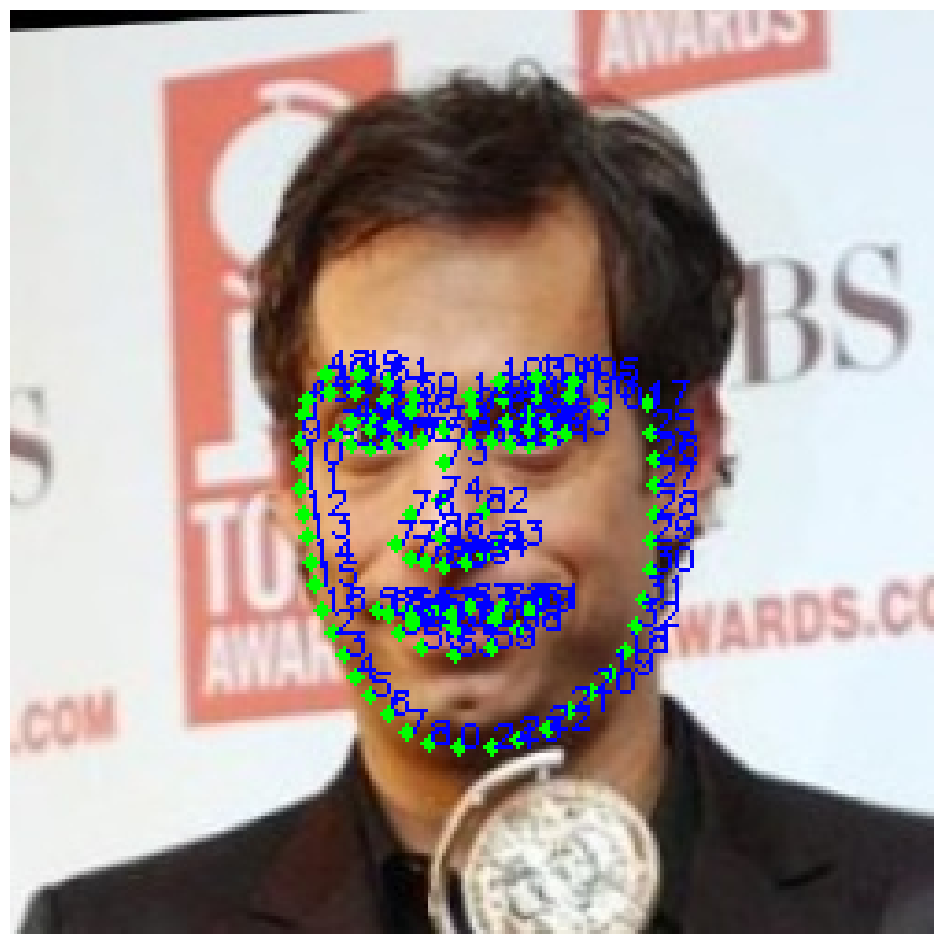

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(test_path)

faces = app.get(img)

face = faces[0]

landmarks = face.landmark_2d_106

for i, point in enumerate(landmarks):

    x, y = point.astype(int)

    cv2.circle(
        img,
        (x, y),
        2,
        (0,255,0),
        -1
    )

    cv2.putText(
        img,
        str(i),
        (x,y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.3,
        (255,0,0),
        1
    )

plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
landmarks = face.landmark_2d_106

for idx in [35,36,37,38,39,40]:
    print(idx, landmarks[idx])

35 [     88.342      114.77]
36 [     92.075      117.18]
37 [     102.58      117.64]
38 [     97.703      113.73]
39 [     107.53      116.48]
40 [     97.632      110.23]


In [ ]:
import numpy as np

def euclidean(p1, p2):
    return np.linalg.norm(p1 - p2)

In [ ]:
def EAR(eye_points):

    A = euclidean(eye_points[1], eye_points[5])
    B = euclidean(eye_points[2], eye_points[4])
    C = euclidean(eye_points[0], eye_points[3])

    return (A + B) / (2.0 * C)

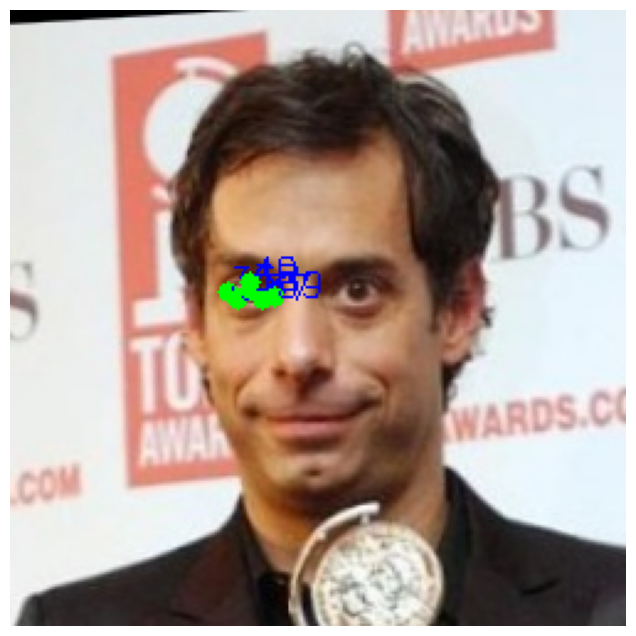

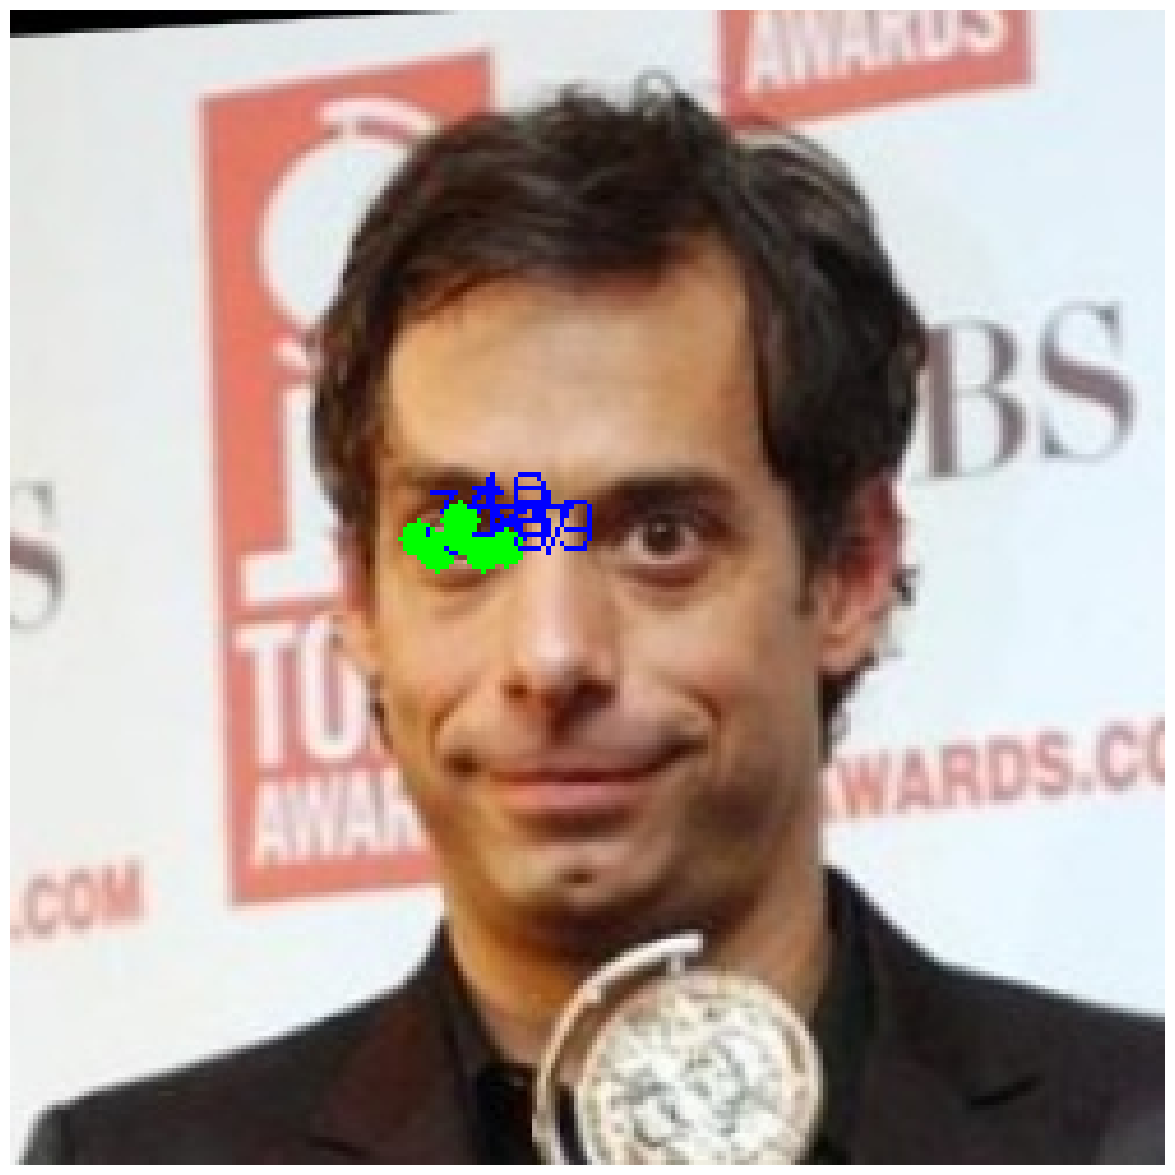

In [ ]:
img = cv2.imread(test_path)

faces = app.get(img)

face = faces[0]

landmarks = face.landmark_2d_106

eye_idx = [35,36,37,38,39,40]

for idx in eye_idx:

    x, y = landmarks[idx].astype(int)

    cv2.circle(img, (x,y), 4, (0,255,0), -1)

    cv2.putText(
        img,
        str(idx),
        (x,y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        1
    )

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

plt.figure(figsize=(15,15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

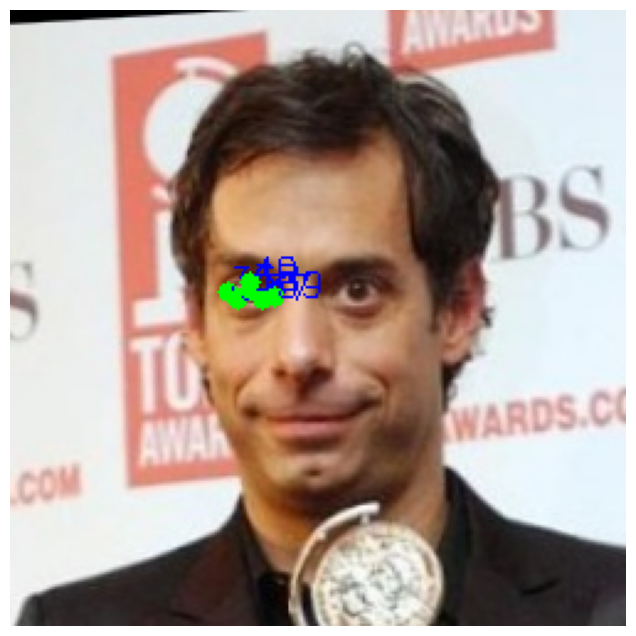

In [ ]:
img = cv2.imread(test_path)

faces = app.get(img)

face = faces[0]

landmarks = face.landmark_2d_106

eye_idx = [35,36,37,38,39,40]

for idx in eye_idx:

    x, y = landmarks[idx].astype(int)

    cv2.circle(img, (x,y), 4, (0,255,0), -1)

    cv2.putText(
        img,
        str(idx),
        (x,y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        1
    )

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
for idx in [35,36,37,38,39,40]:

    x,y = landmarks[idx]

    print(idx, x, y)

35 88.3423 114.76819
36 92.0751 117.18498
37 102.57805 117.63709
38 97.70276 113.72531
39 107.53036 116.48233
40 97.63152 110.22833


In [ ]:
eye = np.array([
    landmarks[35],
    landmarks[36],
    landmarks[37],
    landmarks[39],
    landmarks[38],
    landmarks[40]
])

In [ ]:
import numpy as np

def euclidean(p1,p2):
    return np.linalg.norm(p1-p2)

def calculate_ear(eye):

    A = euclidean(eye[1], eye[5])

    B = euclidean(eye[2], eye[4])

    C = euclidean(eye[0], eye[3])

    ear = (A + B)/(2*C)

    return ear

In [ ]:
ear = calculate_ear(eye)

print("EAR =", ear)

EAR = 0.39331317
